In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from bgflow.utils import (assert_numpy, distance_vectors, distances_from_vectors, 
                          remove_mean, IndexBatchIterator, LossReporter, as_numpy, compute_distances
)
from bgflow import (GaussianMCMCSampler, DiffEqFlow, BoltzmannGenerator, Energy, Sampler, 
                    MultiDoubleWellPotential, MeanFreeNormalDistribution, 
                    KernelDynamics,BlackBoxDynamics, TimeIndependentDynamics, BruteForceEstimator, HutchinsonEstimator, DenseNet)

from bgflow.utils.autograd import brute_force_jacobian_trace

from tbg.gcl import E_GCL_vel, E_GCL, GCL
from tbg.models2 import EGNN


import time

In [3]:
# first define system dimensionality and a target energy/distribution

dim = 8
n_particles = 4
n_dimensions = dim // n_particles

# DW parameters
a=0.9
b=-4
c=0
offset=4

target = MultiDoubleWellPotential(dim, n_particles, a, b, c, offset, two_event_dims=False)

In [4]:
# define a MCMC sampler to sample from the target energy

dw4_data = np.load("data/dw4-dataidx.npy", allow_pickle=True)
all_data = remove_mean(dw4_data[0], n_particles, n_dimensions)
idx = dw4_data[1]
data = all_data[idx[:100000]]
val_data = all_data[idx[100000:500000]]
data_holdout = all_data[idx[-500000:]]
data_holdout.shape

torch.Size([500000, 8])

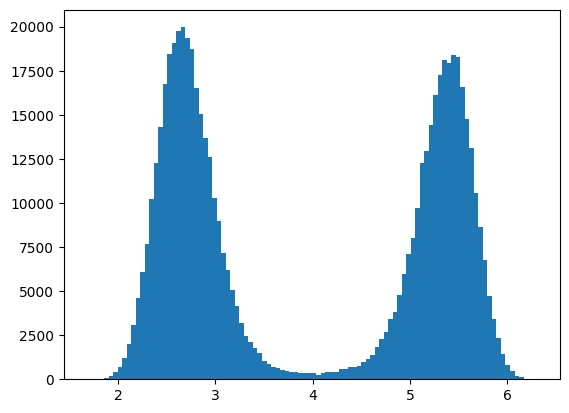

In [5]:
dists_data = as_numpy(compute_distances(data, n_particles, n_dimensions))

plt.hist(dists_data.reshape(-1), bins=100);

In [6]:
n_data = 100000
data_smaller = data[:n_data].clone()
data_smaller = data_smaller
data_smaller.shape

PATH = "models/DW4_equivariant_nODE-egnn-100000"


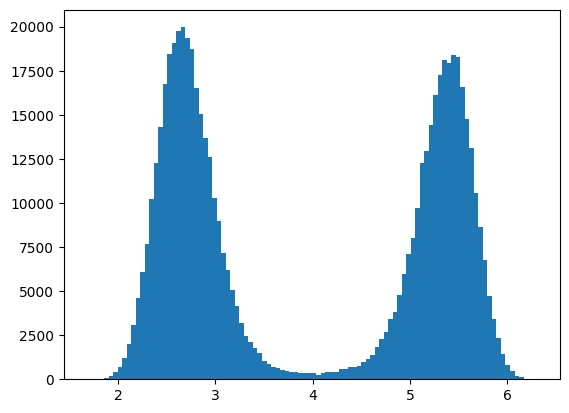

In [7]:
dists_data = as_numpy(compute_distances(data_smaller, n_particles, n_dimensions))

plt.hist(dists_data.reshape(-1), bins=100);

In [8]:
# # now set up a prior
# prior =  MeanFreeNormalDistribution(dim, n_particles, two_event_dims=False).cuda()

# now set up a prior
class MyMeanFreeNormalDistribution(Energy, Sampler):
    """ Mean-free normal distribution. """

    def __init__(self, dim, n_particles, std=1., two_event_dims=True):
        if two_event_dims:
            super().__init__([n_particles, dim // n_particles])
        else:
            super().__init__(dim)
        self._two_event_dims = two_event_dims
        self._dim = dim
        self._n_particles = n_particles
        self._spacial_dims = dim // n_particles
        self.register_buffer("_std", torch.as_tensor(std))

    def forward(self, n_samples, temperature=1.):
        samples = self.sample(n_samples, temperature)
        energy = 0.5 * samples.pow(2).sum(dim=-1, keepdim=True) / self._std ** 2
        return samples, energy.squeeze()
        
    def _energy(self, x):
        x = self._remove_mean(x).view(-1, self._dim)
        # TODO: make consistent
        return 0.5 * x.pow(2).sum(dim=-1, keepdim=True) / self._std ** 2

    def sample(self, n_samples, temperature=1.):
        x = torch.ones((n_samples, self._n_particles, self._spacial_dims), dtype=self._std.dtype,
                         device=self._std.device).normal_(mean=0, std=self._std)
        x = self._remove_mean(x)
        if not self._two_event_dims:
            x = x.view(-1, self._dim)
        return x

    def _remove_mean(self, x):
        x = x.view(-1, self._n_particles, self._spacial_dims)
        x = x - torch.mean(x, dim=1, keepdim=True)
        return x


prior =  MyMeanFreeNormalDistribution(dim, n_particles, two_event_dims=False).cuda()

In [9]:
from tarflow import Model
import math

img_size = 8
channel_size = 1

# we use a small model for fast demonstration, increase the model size for better results
patch_size = 8
channels = 64
blocks = 3
layers_per_block = 2

# try different noise levels to see its effect
noise_std = 0.1

batch_size = 512
lr = 2e-3
# increase epochs for better results
epochs = 100
sample_freq = 10

if torch.cuda.is_available():
    device = 'cuda' 
elif torch.backends.mps.is_available():
    device = 'mps' # if on mac
else:
    device = 'cpu' # if mps not available
    
print(f'using device {device}')

class CosineLRSchedule(torch.nn.Module):
    counter: torch.Tensor

    def __init__(self, optimizer, warmup_steps: int, total_steps: int, min_lr: float, max_lr: float):
        super().__init__()
        self.register_buffer('counter', torch.zeros(()))
        self.warmup_steps = warmup_steps
        self.total_steps = total_steps
        self.optimizer = optimizer
        self.min_lr = min_lr
        self.max_lr = max_lr
        self.set_lr(min_lr)

    def set_lr(self, lr: float) -> float:
        if self.min_lr <= lr <= self.max_lr:
            for pg in self.optimizer.param_groups:
                pg['lr'] = lr
        return max(self.min_lr, min(self.max_lr, lr))

    def step(self) -> float:
        with torch.no_grad():
            counter = self.counter.add_(1).item()
        if self.counter <= self.warmup_steps:
            new_lr = self.min_lr + counter / self.warmup_steps * (self.max_lr - self.min_lr)
            return self.set_lr(new_lr)

        t = (counter - self.warmup_steps) / (self.total_steps - self.warmup_steps)
        new_lr = self.min_lr + 0.5 * (1 + math.cos(math.pi * t)) * (self.max_lr - self.min_lr)
        return self.set_lr(new_lr)
    
tarflow = Model(in_channels=channel_size, img_size=img_size, patch_size=patch_size, 
              channels=channels, num_blocks=blocks, layers_per_block=layers_per_block).to(device)

using device cuda
8 8 1


In [ ]:
# import pdb

# tarflow_optimizer = torch.optim.AdamW(tarflow.parameters(), betas=(0.9, 0.95), lr=2e-3, weight_decay=1e-2)
# n_kl_samples = 256
# n_batch = 256
# batch_iter = IndexBatchIterator(len(data_smaller), n_batch)
# lr_schedule = CosineLRSchedule(optimizer, len(batch_iter), epochs * len(batch_iter), 1e-6, 2e-3)

# def train_tarflow():
#     for epoch in range(epochs):
#         losses = 0
#         for it, idxs in enumerate(batch_iter):
#             x = data_smaller[idxs].to(device)
#             eps = noise_std * torch.randn_like(x)
#             x = x + eps
#             optimizer.zero_grad()
#             z, outputs, logdets = tarflow(x)
#             loss = tarflow.get_loss_mean_free(prior, z, logdets)
#             if not torch.isnan(loss) and not torch.isinf(loss):
#                 loss.backward()
#                 torch.nn.utils.clip_grad_norm_(tarflow.parameters(), 1.0)
#                 torch.nn.utils.clip_grad_value_(tarflow.parameters(), 1.0)
#                 optimizer.step()
#                 lr_schedule.step()
#                 losses += loss.item()
#             else:
#                 print("Loss is NaN. Throwing it out")
                
#         print(f"epoch {epoch} lr {optimizer.param_groups[0]['lr']:.6f} loss {losses / len(batch_iter):.4f}")
            
# train_tarflow()

In [10]:
from tbg.utils import remove_mean as tbg_remove_mean

class EGNN_dynamics_consistency(nn.Module):
    def __init__(
        self,
        n_particles,
        n_dimension,
        hidden_nf=64,
        device="cpu",
        act_fn=torch.nn.SiLU(),
        n_layers=4,
        recurrent=True,
        attention=False,
        condition_time=True,
        tanh=False,
        mode="egnn_dynamics",
        agg="sum",
    ):
        super().__init__()
        self.mode = mode
        if mode == "egnn_dynamics":
            self.egnn = EGNN(
                in_node_nf=2,
                in_edge_nf=1,
                hidden_nf=hidden_nf,
                device=device,
                act_fn=act_fn,
                n_layers=n_layers,
                recurrent=recurrent,
                attention=attention,
                tanh=tanh,
                agg=agg,
            )

        self.device = device
        self._n_particles = n_particles
        self._n_dimension = n_dimension
        self.edges = self._create_edges()
        self._edges_dict = {}
        self.condition_time = condition_time
        # Count function calls
        self.counter = 0

    def forward(self, t, xs, d=None):

        n_batch = xs.shape[0]
        edges = self._cast_edges2batch(self.edges, n_batch, self._n_particles)
        edges = [edges[0], edges[1]]
        x = xs.reshape(n_batch * self._n_particles, self._n_dimension).clone()
        h = torch.ones(n_batch, self._n_particles, 2).to(self.device)
        t = torch.tensor(t).to(xs)
        if t.shape != (n_batch, 1):
            t = t.repeat(n_batch)
        t = t.reshape(n_batch, 1)
        if d is None:
            d = torch.zeros_like(t)

        td = torch.cat([t, d], dim=-1)
        if self.condition_time:
            h = h * td.unsqueeze(1)
        h = h.reshape(n_batch * self._n_particles, 2)
        if self.mode == "egnn_dynamics":
            edge_attr = torch.sum((x[edges[0]] - x[edges[1]]) ** 2, dim=1, keepdim=True)
            _, x_final = self.egnn(h, x, edges, edge_attr=edge_attr)
            vel = x_final - x

        elif self.mode == "gnn_dynamics":
            h = torch.cat([h, x], dim=1)
            vel = self.gnn(h, edges)

        vel = vel.view(n_batch, self._n_particles, self._n_dimension)
        vel = tbg_remove_mean(vel)
        self.counter += 1
        return vel.view(n_batch, self._n_particles * self._n_dimension)

    def _create_edges(self):
        rows, cols = [], []
        for i in range(self._n_particles):
            for j in range(i + 1, self._n_particles):
                rows.append(i)
                cols.append(j)
                rows.append(j)
                cols.append(i)
        return [torch.LongTensor(rows), torch.LongTensor(cols)]

    def _cast_edges2batch(self, edges, n_batch, n_nodes):
        if n_batch not in self._edges_dict:
            self._edges_dict = {}
            rows, cols = edges
            rows_total, cols_total = [], []
            for i in range(n_batch):
                rows_total.append(rows + i * n_nodes)
                cols_total.append(cols + i * n_nodes)
            rows_total = torch.cat(rows_total).to(self.device)
            cols_total = torch.cat(cols_total).to(self.device)

            self._edges_dict[n_batch] = [rows_total, cols_total]
        return self._edges_dict[n_batch]    

In [11]:
import normflows as nf
import larsflow as lf
import pdb

class ComboModel(torch.nn.Module):
    def __init__(self, coupling_flow, flow_model):
        super().__init__()
        self.coupling_flow = coupling_flow
        self.flow_model = flow_model
        
    def forward(self, dt, xs, d=None, training=False):
        use_coupling_flow = torch.abs(d - 1) < 1e-4
        _, v_coupling_flow, logdets= self.coupling_flow(xs)
        v_coupling_flow = v_coupling_flow[-1]
        if training:
            v_coupling_flow = v_coupling_flow - xs
        v_flow = self.flow_model(dt, xs, d)
        v_coupling_flow = v_coupling_flow[use_coupling_flow.squeeze()]
        coupling_target = v_flow[use_coupling_flow.squeeze()].detach()
        return v_flow, v_coupling_flow, coupling_target

net_dynamics = EGNN_dynamics_consistency(n_particles=n_particles, device='cuda',  n_dimension=dim // n_particles, hidden_nf=256,
    act_fn=torch.nn.SiLU(), n_layers=5, recurrent=True, tanh=True, attention=True, condition_time=True, mode='egnn_dynamics', agg='sum')

# realnvp = make_wrapped_normflow_realnvp(8)
combo_model = ComboModel(tarflow, net_dynamics).cuda()

In [12]:
# Initialize divergence estimators
brute_force_estimator = BruteForceEstimator()

In [13]:
bb_dynamics = BlackBoxDynamics(
    dynamics_function=net_dynamics,
    divergence_estimator=brute_force_estimator
)

In [14]:
flow = DiffEqFlow(
    dynamics=bb_dynamics
)

In [15]:
# having a flow and a prior, we can now define a Boltzmann Generator

bg = BoltzmannGenerator(prior, flow, target).cuda()

In [16]:
# use DTO in the training process
flow._use_checkpoints = True

# Anode options
options={
    "Nt": 20,
    "method": "RK4"
}
flow._kwargs = options

In [20]:
# train with convex mixture of NLL and KL loss

n_kl_samples = 256
n_batch = 256
batch_iter = IndexBatchIterator(len(data_smaller), n_batch)

optim = torch.optim.AdamW(combo_model.flow_model.parameters(), lr=5e-4)
tarflow_optimizer = torch.optim.AdamW(tarflow.parameters(), betas=(0.9, 0.95), lr=5e-4, weight_decay=1e-2)

lr_schedule_flow = CosineLRSchedule(optim, len(batch_iter), epochs * len(batch_iter), 1e-6, 5e-4)
lr_schedule_tarflow = CosineLRSchedule(optim, len(batch_iter), epochs * len(batch_iter), 1e-6, 5e-4)
n_epochs = 1
n_report_steps = 5

# mixing parameter

reporter = LossReporter("NLL", "Consistency")
val_losses = []

In [21]:
# start with 5e-4

for g in optim.param_groups:
     g['lr'] = 5e-4

In [22]:
d_values = torch.tensor([1/128, 1/64, 1/32, 1/16,1/8,1/4, 1/2])

In [23]:
import pdb
from tqdm import tqdm

sigma = 0.01
for epoch in tqdm(range(n_epochs)):
    if epoch ==200:
        for g in optim.param_groups:
             g['lr'] = 5e-5
    for it, idxs in enumerate(batch_iter):

        optim.zero_grad()
        tarflow_optimizer.zero_grad()

        x1 = data_smaller[idxs].cuda()
        batchsize = x1.shape[0]
        t = torch.rand(batchsize, 1).cuda()
        indices = torch.randint(0, len(d_values), (batchsize,))
        d = d_values[indices].unsqueeze(-1).cuda()
        d_input = d.clone()
        d_input[d_input<1/100] = 0

        x0 = prior.sample(batchsize)

        mu_t = x0 * (1 - t) + x1 * t
        sigma_t = sigma
        noise = prior.sample(batchsize)
        x = mu_t + sigma_t * noise
        ut = x1 - x0
        vt = bg.flow._dynamics._dynamics._dynamics_function(t, x)
        loss = torch.mean((vt - ut) ** 2)
        # loss.backward()
        s_t = bg.flow._dynamics._dynamics._dynamics_function(t, x, d_input)
        # use mu_t here directly?
        x_td = x + s_t * d
        s_td = bg.flow._dynamics._dynamics._dynamics_function(t+d, x_td, d_input)
        s_target = (s_t + s_td).detach() / 2
        v_td, v_td_tarflow, s_target_tarflow = combo_model(t, x, 2*d, training=True)
        consistency_loss = torch.mean((v_td - s_target) ** 2)
        total_loss = loss + consistency_loss
        
        tarflow_loss = torch.mean((v_td_tarflow - s_target_tarflow) ** 2)

        if not torch.isnan(total_loss) and not torch.isinf(total_loss):
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(combo_model.parameters(), 1.0)
            torch.nn.utils.clip_grad_value_(combo_model.parameters(), 1.0)
            optim.step()
            lr_schedule_flow.step()

        if not torch.isnan(tarflow_loss):
            tarflow_loss.backward()
            torch.nn.utils.clip_grad_norm_(tarflow.parameters(), 1.0)
            torch.nn.utils.clip_grad_value_(tarflow.parameters(), 1.0)
            tarflow_optimizer.step()
            lr_schedule_tarflow.step()

        #reporter.report(loss, consistency_loss, tarflow_loss)

        if it % n_report_steps == 0:
            print("\repoch: {0}, iter: {1}/{2}, loss: {3:.4}, consistency_loss: {4:.4}, tarflow_loss: {4: .4}".format(
                    epoch,
                    it,
                    len(batch_iter),
                    total_loss.item(),
                    consistency_loss.item(),
                    tarflow_loss.item()
                ), end="")


  0%|                                                                                                                                                                                                                          | 0/1 [00:00<?, ?it/s]/tmp/ipykernel_2207407/953134320.py:51: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t).to(xs)


epoch: 0, iter: 385/390, loss: 2.201, consistency_loss: 0.004249, tarflow_loss:  0.0042495

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:18<00:00, 18.22s/it]

epoch: 0, iter: 390/390, loss: 2.446, consistency_loss: 0.005643, tarflow_loss:  0.005643

In [ ]:
reporter.plot()

In [ ]:
reporter.plot()

In [ ]:
sum(p.numel() for p in bg.parameters() if p.requires_grad)

In [ ]:
PATH = "models/DW4_shortcut_tarflow_separate_combo"
PATH_TARFLOW = "models/DW4_shortcut_tarflow_separate_tarflow"
#torch.save(bg.state_dict(), PATH)
#bg.load_state_dict(torch.load(PATH))
torch.save(combo_model.state_dict(), PATH)
combo_model.load_state_dict(torch.load(PATH))

torch.save(tarflow.state_dict(), PATH)
tarflow.load_state_dict(torch.load(PATH_TARFLOW))

In [ ]:
class BruteForceEstimatorFast(torch.nn.Module):
    """
    Exact bruteforce estimation of the divergence of a dynamics function.
    """

    def __init__(self):
        super().__init__()

    def forward(self, dynamics, t, xs):
        """
        Computes the change of the system `dxs` due to a time independent dynamics function.
        Furthermore, also computes the exact change of log density
        which is equal to the divergence of the change `dxs`.

        Parameters
        ----------
        dynamics : torch.nn.Module
            A dynamics function that computes the change of the system and its density.
        t : PyTorch tensor
            The current time
        xs : PyTorch tensor
            The current configuration of the system

        Returns
        -------
        dxs, -divergence: PyTorch tensors
            The combined state update of shape `[n_batch, n_dimensions]`
            containing the state update of the system state `dx/dt`
            (`dxs`) and the negative update of the log density (`-divergence`)
        """

        with torch.set_grad_enabled(True):
            xs.requires_grad_(True)
            x = [xs[:, [i]] for i in range(xs.size(1))]

            dxs = dynamics(t, torch.cat(x, dim=1))

            assert len(dxs.shape) == 2, "`dxs` must have shape [n_btach, system_dim]"
            divergence = 0
            for i in range(xs.size(1)):
                divergence += torch.autograd.grad(dxs[:, [i]], x[i], torch.ones_like(dxs[:, [i]]), retain_graph=True)[0]

        return dxs, -divergence.view(-1, 1)
    
brute_force_estimator_fast = BruteForceEstimatorFast()
# use OTD in the evaluation process
bb_dynamics._divergence_estimator = brute_force_estimator_fast
bg.flow._integrator_atol = 1e-3
bg.flow._integrator_rtol = 1e-3
flow._use_checkpoints = False

## Sampling with dopri5

In [ ]:
import tqdm

n_samples = 1000
n_sample_batches = 1
latent_np = np.empty(shape=(0))
samples_np = np.empty(shape=(0))
log_w_np = np.empty(shape=(0))
energies_np = np.empty(shape=(0))
distances_x_np = np.empty(shape=(0))

for i in tqdm.tqdm(range(n_sample_batches)):
    with torch.no_grad():
        samples, latent, dlogp = bg.sample(n_samples, with_latent=True, with_dlogp=True)
        #latent = latent[0]
        log_weights = bg.log_weights_given_latent(samples, latent, dlogp, normalize=False).detach().cpu().numpy()
        latent_np = np.append(latent_np, latent.detach().cpu().numpy())
        samples_np = np.append(samples_np, samples.detach().cpu().numpy())
        distances_x = distances_from_vectors(distance_vectors(samples.view(-1, n_particles, n_dimensions))).detach().cpu().numpy().reshape(-1)
        distances_x_np = np.append(distances_x_np, distances_x)

        log_w_np = np.append(log_w_np, log_weights)
        energies = target.energy(samples).detach().cpu().numpy()
        energies_np = np.append(energies_np, energies)
        

latent_np = latent_np.reshape(-1, dim)
samples_np = samples_np.reshape(-1, dim)

In [ ]:
from bgflow.bg import sampling_efficiency
sampling_efficiency(torch.from_numpy(log_w_np)).item()

In [ ]:
energies_data = target.energy(data).detach().cpu().numpy()
#energies_compare = sampls.energy()
energies_bg = energies_np#target.energy(samples[:, :dim]).detach().cpu().numpy()

energies_prior = target.energy(latent).detach().cpu().numpy()

min_energy = min(energies_data.min(), energies_bg.min(), energies_prior.min())
max_energy = max(energies_data.max(), energies_bg.max(), energies_prior.max())

plt.figure(figsize=(13,8))
efac = 1
#plt.hist(energies_prior, bins=100, density=True, range=(min_energy, 0), alpha=0.4, color="b", histtype='step', linewidth=4,
#         label="prior");
plt.hist(energies_bg, bins=100, density=True,  range=(min_energy, 0), alpha=0.4, histtype='step', linewidth=4,
         color="r", label="eqBG");

plt.hist(energies_data, bins=100, density=True, range=(min_energy, 0), alpha=0.4, color="g", histtype='step', linewidth=4, 
         label="MCMC data (test)");
plt.hist(energies_bg.reshape(-1), bins=100, density=True,  range=(min_energy, 0), alpha=0.4, histtype='step', linewidth=4,
         color="b", label="eqBG weighted samples", weights=np.exp(log_w_np));
#plt.hist(energies_compare, bins=100, density=True, range=(energies_bg.min(), 0), alpha=0.4, color="y", 
#         label="MCMC data (test)");

plt.xlabel("u(x)", fontsize=45)  
plt.xticks(fontsize=45) 
plt.yticks(fontsize=45);
plt.legend( fontsize=25);

In [ ]:
dists = distances_from_vectors(
            distance_vectors(data_holdout.view(-1, n_particles, dim // n_particles)))
dists_prior = distances_from_vectors(
            distance_vectors(latent.view(-1, n_particles, dim // n_particles)))
from bgflow.utils import as_numpy
def distance_energy(d):
    d = d - offset
    return c * d**4 + b * d**2
d = torch.linspace(1, 7, 1000).view(-1, 1) + 1e-6 
u = torch.exp(-(distance_energy(d).view(-1, 1) - offset )).sum(dim=-1, keepdim=True)  * d.abs() **(dim // n_particles - 1)
Z = (u * 1 / (len(d) / (d.max() - d.min()))).sum()
e = u / Z #* 1.1

plt.figure(figsize=(16,9))
#plt.plot(d, e, label="Groundtruth", linewidth=4, alpha = 0.5)
plt.hist(as_numpy(dists.view(-1)), bins=100, label="holdout samples", alpha=0.5, density=True, histtype='step', linewidth=4);
plt.hist(distances_x_np, bins=100, label="bg samples", alpha=0.7, density=True, histtype='step', linewidth=4, range=(0,8));
plt.hist(distances_x_np, bins=100, label="reweighted bg samples", alpha=0.7, density=True, histtype='step',
         linewidth=4, weights=np.repeat(np.exp(log_w_np).flatten(), n_particles*(n_particles-1)), range=(0,8));
plt.xlim(0,7)
plt.legend(fontsize=25)
plt.xlabel("Dinstance", fontsize=45)  
plt.xticks(fontsize=45) 
plt.yticks(fontsize=45);
plt.title("Distance distribution", fontsize=45);


In [ ]:
# count the steps here

bb_dynamics._dynamics_function.counter = 0
with torch.no_grad():
    samples, latent, dlogp = bg.sample(n_samples, with_latent=True, with_dlogp=True)
bb_dynamics._dynamics_function.counter

# Sampling with shortcut models

In [ ]:
# inference with Euler
def euler_solve(model, x0, s):
    """
    model: nn.Module representing v(x,t)
    x0: (batch_size, input_dim) initial samples from p0(x)
    T: end time
    N: number of Euler steps
    """
    N = int(1/s)
    x = x0
    t = torch.zeros(x0.shape[0],1).to(x)
    dt = torch.ones(x0.shape[0],1).to(x) * s
  

    for step in range(N):
        # Forward Euler update
        with torch.no_grad():
            dx = model(t, x, dt)  # v(x, t)
            x = x + dt * dx   # x_{k+1} = x_k + dt * v(x_k, t_k)
            t = t + dt        # increment time

    return x


In [ ]:
x0 = prior.sample(10000)

In [ ]:
d_values = torch.tensor([1/128, 1/64, 1/32, 1/16,1/8,1/4, 1/2, 1])
for dval in d_values:
    x1 = euler_solve(bg.flow._dynamics._dynamics._dynamics_function, x0=x0, s=torch.tensor(dval))


    plt.figure(figsize=(16,9))
    distances_x_fast = distances_from_vectors(distance_vectors(x1.view(-1, n_particles, n_dimensions))).detach().cpu().numpy().reshape(-1)
    
    plt.hist(as_numpy(dists.view(-1)), bins=100, label="holdout samples", alpha=0.5, density=True, histtype='step', linewidth=4);
    plt.hist(distances_x_np, bins=100, label="bg samples true", alpha=0.7, density=True, histtype='step', linewidth=4, range=(0,8));
    plt.hist(distances_x_fast, bins=100, label="bg samples fast", alpha=0.7, density=True, histtype='step', linewidth=4, range=(0,8));
    
    plt.xlim(0,7)
    plt.legend(fontsize=25)
    plt.xlabel("Disttance", fontsize=45)  
    plt.xticks(fontsize=45) 
    plt.yticks(fontsize=45);
    plt.title(f"Distance distribution {dval} steps", fontsize=45);
    plt.show()

    energies_data = target.energy(data).detach().cpu().numpy()
    #energies_compare = sampls.energy()
    energies_bg = target.energy(x1).detach().cpu().numpy()
    
    energies_prior = target.energy(latent).detach().cpu().numpy()
    
    min_energy = min(energies_data.min(), energies_bg.min(), energies_prior.min())
    max_energy = max(energies_data.max(), energies_bg.max(), energies_prior.max())
    
    plt.figure(figsize=(13,8))
    efac = 1
    
    plt.hist(energies_bg, bins=100, density=True,  range=(min_energy, 0), alpha=0.4, histtype='step', linewidth=4,
             color="r", label="BG");
    
    plt.hist(energies_data, bins=100, density=True, range=(min_energy, 0), alpha=0.4, color="g", histtype='step', linewidth=4, 
             label="Target samples");
    
    
    plt.xlabel("u(x)", fontsize=45)  
    plt.xticks(fontsize=45) 
    plt.yticks(fontsize=45);
    plt.legend( fontsize=25);
    plt.title(f"Energy distribution {dval} steps")
    plt.show()

## Including the likelihood

In [ ]:
from bgflow import BlackBoxDynamics, TimeIndependentDynamics, BruteForceEstimator, HutchinsonEstimator, DenseNet
from bgflow.utils.autograd import brute_force_jacobian_trace
import torch


class BruteForceEstimatorFastStep(torch.nn.Module):
    """
    Exact bruteforce estimation of the divergence of a dynamics function.
    """

    def __init__(self):
        super().__init__()

    def forward(self, dynamics, t, xs, s):
        """
        Computes the change of the system `dxs` due to a time independent dynamics function.
        Furthermore, also computes the exact change of log density
        which is equal to the divergence of the change `dxs`.

        Parameters
        ----------
        dynamics : torch.nn.Module
            A dynamics function that computes the change of the system and its density.
        t : PyTorch tensor
            The current time
        xs : PyTorch tensor
            The current configuration of the system
        s : PyTorch tensor
            The step size
        Returns
        -------
        dxs, -divergence: PyTorch tensors
            The combined state update of shape `[n_batch, n_dimensions]`
            containing the state update of the system state `dx/dt`
            (`dxs`) and the negative update of the log density (`-divergence`)
        """

        with torch.set_grad_enabled(True):
            xs.requires_grad_(True)
            x = [xs[:, [i]] for i in range(xs.size(1))]

            dxs = dynamics(t, torch.cat(x, dim=1), s)

            assert len(dxs.shape) == 2, "`dxs` must have shape [n_btach, system_dim]"
            divergence = 0
            for i in range(xs.size(1)):
                divergence += torch.autograd.grad(dxs[:, [i]], x[i], torch.ones_like(dxs[:, [i]]), retain_graph=True)[0]

        return dxs, divergence.view(-1, 1)
    
brute_force_estimator_fast_step = BruteForceEstimatorFastStep()


In [ ]:
import normflows as nf
import larsflow as lf
from fab.wrappers.normflows import WrappedNormFlowModel
from fab.trainable_distributions import TrainableDistribution
import pdb

def make_normflow_flow(dim: int,
                       n_flow_layers: int,
                       layer_nodes_per_dim: int,
                       act_norm: bool):
    # Define list of flows
    flows = []
    layer_width = dim * layer_nodes_per_dim
    for i in range(n_flow_layers):
        # Neural network with two hidden layers having 32 units each
        # Last layer is initialized by zeros making training more stable
        d = int((dim / 2) + 0.5)
        param_map = nf.nets.MLP([d, layer_width, layer_width, 2 * (dim - d)], init_zeros=True)
        # Add flow layer
        flows.append(nf.flows.AffineCouplingBlock(param_map, scale_map="exp"))
        # Swap dimensions
        flows.append(nf.flows.InvertibleAffine(dim))
        # ActNorm
        #if act_norm:
        #    flows.append(nf.flows.ActNorm(dim))
    return flows

def make_wrapped_normflow_realnvp(
        dim: int,
        n_flow_layers: int = 5,
        layer_nodes_per_dim: int = 10,
        act_norm: bool = True) -> TrainableDistribution:
    """Created a wrapped normflows distribution using the example from the normflows page."""
    base = prior
    flows = make_normflow_flow(dim, n_flow_layers=n_flow_layers,
                               layer_nodes_per_dim=layer_nodes_per_dim,
                               act_norm=act_norm)
    model = nf.NormalizingFlow(base, flows).cuda()
    wrapped_dist = WrappedNormFlowModel(model)
    if act_norm:
        wrapped_dist.sample((500,))  # ensure we call sample to initialise the ActNorm layers
    return wrapped_dist
    
realnvp = make_wrapped_normflow_realnvp(8,  n_flow_layers=8, layer_nodes_per_dim=64)
losses = []

In [ ]:
optim2 = torch.optim.AdamW(realnvp.parameters(), weight_decay=0.01)

for epoch in range(n_epochs):
    if epoch ==200:
        for g in optim.param_groups:
             g['lr'] = 5e-5
    for it, idxs in enumerate(batch_iter):
        optim2.zero_grad()
        x1 = data_smaller[idxs].cuda()
        batchsize = x1.shape[0]
        t = torch.rand(batchsize, 1).cuda()
        t = torch.zeros_like(t)
        indices = torch.randint(0, len(d_values), (batchsize,))
        d_input = torch.ones_like(t)
        x0 = prior.sample(batchsize)
        s_t = bg.flow._dynamics._dynamics._dynamics_function(t, x0, d_input).detach()
        x1 = s_t + x0
        x1hat = realnvp._nf_model.inverse(x0)
        loss = torch.mean((x1 - x1hat) ** 2)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(realnvp.parameters(), 1.0)
        optim2.step()
        #reporter.report(loss)
        losses.append(loss)
    print(epoch, losses[-1].item())
    if epoch %10 == 0:
        loss_tensor = torch.stack(losses)

        plt.plot(loss_tensor.detach().cpu().numpy())
        plt.ylim(0,0.2)
        plt.show()

In [ ]:
loss_tensor = torch.stack(losses)

plt.plot(loss_tensor.detach().cpu().numpy())
plt.ylim(0,0.2)

In [ ]:
def euler_solve_with_logp(model, divergence, x0, s, use_shortcut=True):
    """
    model:   nn.Module that computes v(x, t).
    x0:      (batch_size, dim) initial samples.
    logp0:   (batch_size,) initial log p(x0).
    T:       final time.
    N:       number of Euler steps.

    Returns:
        xN:    (batch_size, dim) final samples at t=T.
        logpN: (batch_size,) log probability of xN.
    """
    N = int(1/s)
    x = x0
    t = torch.zeros(x0.shape[0],1).to(x)
    dt = torch.ones(x0.shape[0],1).to(x) * s
    logp = torch.zeros(x0.shape[0],1).to(x)
    for _ in range(N):
        # Make sure x is differentiable so we can compute div
        x.requires_grad_(True)
        # 2. Compute velocity and divergence
        v, div_v = divergence(model, t, x, dt if use_shortcut else None)

        # 3. Euler update for x
        x_next = x + dt * v

        # 4. Euler update for log p
        # d/dt [log p] = - div(v), so forward Euler => logp_next = logp - dt * div_v
        logp_next = logp - dt * div_v

        # Detach x_next & logp_next to avoid building huge graphs
        x = x_next.detach()
        logp = logp_next.detach()

        # Increase time
        t = t + dt
    return x, logp


In [ ]:
x0.shape

In [ ]:
n_steps = 2
x1, dlogp1 = euler_solve_with_logp(bg.flow._dynamics._dynamics._dynamics_function, brute_force_estimator_fast_step, x0=x0, s=torch.tensor(1/n_steps))
x1_normal, dlogp1_normal = euler_solve_with_logp(bg.flow._dynamics._dynamics._dynamics_function, brute_force_estimator_fast_step, x0=x0, s=torch.tensor(1/n_steps), use_shortcut=False)


In [ ]:
plt.hist(as_numpy(dlogp1), bins=100);


In [ ]:
energies_data = target.energy(data).detach().cpu().numpy()
#energies_compare = sampls.energy()
energies_bg = target.energy(x1).detach().cpu().numpy()
log_weights = bg.log_weights_given_latent(x1, x0, -dlogp1, normalize=False).detach().cpu().numpy()
log_w_np = as_numpy(log_weights)
energies_prior = target.energy(x0).detach().cpu().numpy()

min_energy = min(energies_data.min(), energies_bg.min(), energies_prior.min())
max_energy = max(energies_data.max(), energies_bg.max(), energies_prior.max())

plt.figure(figsize=(13,8))
efac = 1
#plt.hist(energies_prior, bins=100, density=True, range=(min_energy, 0), alpha=0.4, color="b", histtype='step', linewidth=4,
#         label="prior");
plt.hist(energies_data, bins=100, density=True, range=(min_energy, 0), alpha=0.4, color="g", histtype='step', linewidth=4, 
         label="Target");
plt.hist(energies_bg, bins=100, density=True,  range=(min_energy, 0), alpha=0.4, histtype='step', linewidth=4,
         color="r", label=f"BG samples shortcut model - {n_steps} steps");

plt.hist(energies_bg.reshape(-1), bins=100, density=True,  range=(min_energy, 0), alpha=0.4, histtype='step', linewidth=4,
         color="b", label=f"Weighted BG samples shortcut model - {n_steps} steps", weights=np.exp(log_w_np));
#plt.hist(energies_compare, bins=100, density=True, range=(energies_bg.min(), 0), alpha=0.4, color="y", 
#         label="MCMC data (test)");
plt.title("DW4 Energy distribution", fontsize=45)
plt.xlabel("u(x)", fontsize=45)  
plt.xticks(fontsize=45) 
plt.yticks(fontsize=45);
plt.legend(fontsize=25);

In [ ]:
plt.hist(log_w_np, bins=100);


In [ ]:
from bgflow.bg import sampling_efficiency
sampling_efficiency(torch.from_numpy(log_w_np)).item()

In [ ]:
plt.figure(figsize=(16,9))
distances_x_fast = distances_from_vectors(distance_vectors(x1.view(-1, n_particles, n_dimensions))).detach().cpu().numpy().reshape(-1)

plt.hist(as_numpy(dists.view(-1)), bins=100, label="holdout samples", alpha=0.5, density=True, histtype='step', linewidth=4);
plt.hist(distances_x_np, bins=100, label="bg samples true", alpha=0.7, density=True, histtype='step', linewidth=4, range=(0,8));
plt.hist(distances_x_fast, bins=100, label="bg samples fast", alpha=0.7, density=True, histtype='step', linewidth=4, range=(0,8));
#plt.hist(distances_x_fast[1::12], bins=100, label="bg samples fast reweighted", alpha=0.7, density=True, histtype='step', linewidth=4, range=(0,8), weights=np.exp(log_w_np));

plt.xlim(0,7)
plt.legend(fontsize=25)
plt.xlabel("Dinstance", fontsize=45)  
plt.xticks(fontsize=45) 
plt.yticks(fontsize=45);
plt.title("Distance distribution", fontsize=45);


In [ ]:
plt.figure(figsize=(16,9))
distances_x_fast = distances_from_vectors(distance_vectors(x1.view(-1, n_particles, n_dimensions))).detach().cpu().numpy().reshape(-1)
distances_x_normal = distances_from_vectors(distance_vectors(x1_normal.view(-1, n_particles, n_dimensions))).detach().cpu().numpy().reshape(-1)

plt.hist(as_numpy(dists.view(-1)), bins=100, label="Target samples", alpha=0.9, density=True, histtype='step', linewidth=4);
plt.hist(distances_x_normal, bins=100, label=f"BG samples - {n_steps} steps", alpha=0.9, density=True, histtype='step', linewidth=4, range=(0,8));
plt.hist(distances_x_fast, bins=100, label=f"BG samples shortcut model - {n_steps} steps", alpha=0.9, density=True, histtype='step', linewidth=4, range=(0,8));

plt.xlim(0,7)
plt.legend(fontsize=25)
plt.xlabel("Dinstance", fontsize=45)  
plt.xticks(fontsize=45) 
plt.yticks(fontsize=45);
plt.title("DW4 Distance distribution", fontsize=45);


In [ ]:
energies_data = target.energy(data).detach().cpu().numpy()
#energies_compare = sampls.energy()
energies_bg = target.energy(x1).detach().cpu().numpy()
energies_bg_normal = target.energy(x1_normal).detach().cpu().numpy()
log_weights = bg.log_weights_given_latent(x1, x0, -dlogp1, normalize=False).detach().cpu().numpy()
log_w_np = as_numpy(log_weights)
energies_prior = target.energy(latent).detach().cpu().numpy()

min_energy = min(energies_data.min(), energies_bg.min(), energies_prior.min())
max_energy = max(energies_data.max(), energies_bg.max(), energies_prior.max())

plt.figure(figsize=(13,8))
efac = 1
#plt.hist(energies_prior, bins=100, density=True, range=(min_energy, 0), alpha=0.4, color="b", histtype='step', linewidth=4,
#         label="prior");
plt.hist(energies_data, bins=100, density=True, range=(min_energy, 0), alpha=0.9, histtype='step', linewidth=4, 
         label="Target samples");
plt.hist(energies_bg_normal, bins=100, density=True,  range=(min_energy, 0), alpha=0.9, histtype='step', linewidth=4,
         label=f"BG samples - {n_steps} steps");
plt.hist(energies_bg, bins=100, density=True,  range=(min_energy, 0), alpha=0.9, histtype='step', linewidth=4,
         label=f"BG samples shortcut model - {n_steps} steps");


#plt.hist(energies_compare, bins=100, density=True, range=(energies_bg.min(), 0), alpha=0.4, color="y", 
#         label="MCMC data (test)");
plt.title("DW4 Energy distribution", fontsize=45)
plt.xlabel("u(x)", fontsize=45)  
plt.xticks(fontsize=45) 
plt.yticks(fontsize=45);
plt.legend(fontsize=25);

In [ ]:
energies_bg.mean(), energies_bg_normal.mean()

In [ ]:
PATH = "models/DW4_shortcut_big_realnvp_v3"
# torch.save(realnvp.state_dict(), PATH)
# realnvp.load_state_dict(torch.load(PATH))

In [25]:
results = []
for i in range(100):
    x0 = prior.sample(10_000)
    
    z, outputs, dlogp1 = tarflow(x0)
    x1 = outputs[-1]
    n_steps=1
    results.append([x0.cpu(), x1.detach().cpu(), dlogp1.detach().cpu()])


RuntimeError: (*bias): last dimension must be contiguous

In [ ]:
tensors = []
for j in range(3):
    tensors.append(torch.concat(list(zip(*results))[j]).cuda())
x0, x1, dlogp1 = tensors

    

In [ ]:
energies_data = target.energy(data).detach().cpu().numpy()
#energies_compare = sampls.energy()
energies_bg = target.energy(x1).detach().cpu().numpy()
print(energies_bg.shape)
log_weights = bg.log_weights_given_latent(x1, x0, dlogp1.reshape(-1,1), normalize=False).detach().cpu().numpy()
log_w_np = as_numpy(log_weights)
energies_prior = target.energy(data).detach().cpu().numpy()
print(np.exp(log_w_np).shape)
min_energy = min(energies_data.min(), energies_bg.min(), energies_prior.min())
max_energy = max(energies_data.max(), energies_bg.max(), energies_prior.max())

plt.figure(figsize=(13,8))
efac = 1
#plt.hist(energies_prior, bins=100, density=True, range=(min_energy, 0), alpha=0.4, color="b", histtype='step', linewidth=4,
#         label="prior");
plt.hist(energies_data, bins=100, density=True, range=(min_energy, 0), alpha=0.4, color="g", histtype='step', linewidth=4, 
         label="Target");
plt.hist(energies_bg, bins=100, density=True,  range=(min_energy, 0), alpha=0.4, histtype='step', linewidth=4,
         color="r", label=f"BG samples shortcut model - {n_steps} steps");

plt.hist(energies_bg.reshape(-1), bins=100, density=True,  range=(min_energy, 0), alpha=0.4, histtype='step', linewidth=4,
         color="b", label=f"Weighted BG samples shortcut model - {n_steps} steps", weights=np.exp(log_w_np));
#plt.hist(energies_compare, bins=100, density=True, range=(energies_bg.min(), 0), alpha=0.4, color="y", 
#         label="MCMC data (test)");
plt.title("DW4 Energy distribution", fontsize=45)
plt.xlabel("u(x)", fontsize=45)  
plt.xticks(fontsize=45) 
plt.yticks(fontsize=45);
plt.legend(fontsize=25);

In [ ]:
from bgflow.bg import sampling_efficiency
sampling_efficiency(torch.from_numpy(log_w_np)).item()